# PETaDex ORF Biochemical Properties Precompute

> **Author:** Angela Jiang  
> **Date Started:** 2026-07-01  
> **Date Finished:** 2026-09-20  
> **Input:** `petadex.catalytic_orfs.v1.1.fa` (PETaDex catalytic ORF corpus);
> `signalp6_orf_predictions` (cleavage sites for secreted ORFs)  
> **Output:** `orf_biochemical_properties` (PostgreSQL table); full CSVs archived at
> s3://automated-metadata/biochemical-properties-full-orfs/ and
> s3://automated-metadata/biochemical-properties-mature/

---

## 1. Objective

The goal of this pipeline is to precompute sequence-derived biochemical
properties for every PETaDex catalytic ORF and load them into a queryable
PostgreSQL table. Properties calculated include: sequence length, molecular weight, isoelectric point, GRAVY index, instability index, and aromaticity.

### 1.1. Place in the Project

Properties like hydrophobicity, isoelectric point, and stability are useful
first-pass filters when triaging candidate plastic-degrading enzymes for wet-lab
validation; for example, prioritising sequences that are predicted stable and
soluble. It also allows repeated downstream queries and processing for different analytical purposes without recomputation every time.

Building on top of completed SignalP predictions (see Issue94) done on the database, approximately 14% of the ORFS within the database possess signal peptides. The biochemical properties of these sequences in both cleaved and uncleaved forms are calculated. The values of the properties of cleaved sequences are more accurate to the characteristics of the mature enzyme, whereas the uncleaved sequences remain potentially insightful as a comparator set and as potential indication into post-translational behaviors that impact expression efficiency.

## 2. Experiment

### 2.0. Install requirements

1. Biopython (`Bio.SeqUtils.ProtParam`)
2. Python 3.9+ with `boto3` and `numpy`
3. PostgreSQL client (`psql`) — for the cleavage-site export (2.3) and loading
4. AWS CLI v2 — for archiving output parts to S3

Biochemical features are computed with
`Bio.SeqUtils.ProtParam.ProteinAnalysis`, selected because it computes
deterministic sequence-derived properties without alignment, structure
prediction, or trained inference — no GPU and no external database lookups are
required. The ORF sequence is uppercased and stripped of
terminal stop symbols (`*`) before any slicing or validation.

### 2.1. Pass 1 — full-ORF properties

The first pass (`precompute_biochem_resumable.py`, Appendix A) streams the ORF
FASTA record by record and computes the five properties on the full translated
sequence for every ORF.

Every PETaDex ORF record uses the following pipe-delimited header:

```text
>{orf_id}|{genbank_accession}|{library_id}|{contig_id}|{orf_start}|{orf_end}|{orf_type}
```

The first field is used:

```python
orf_id = int(header_first_token.split("|", 1)[0])
```
The pipeline is essentially:

```text
PETaDex ORF FASTA (109 GB, EBS)
  -> streamed record-by-record
  -> per-sequence Biopython ProteinAnalysis calculation
  -> gzip-compressed CSV part files
  -> manifest/checkpoint JSON
  -> S3 archive + PostgreSQL COPY load
```

Output parts are written atomically: each part is written to
`*.csv.gz.tmp` and renamed to `*.csv.gz` once complete. A `manifest.json`
checkpoint records progress and status counts after each completed part. Output
part size is set by `--rows-per-file` (production: `5,000,000`).

```bash
nohup python precompute_biochem_resumable.py \
  --fasta petadex.catalytic_orfs.v1.1.fa \
  --out-dir ./biochem_FULL \
  --rows-per-file 5000000 \
  --progress-every 100000 \
  --resume \
  > biochem_FULL.nohup.log 2>&1 &
```

**Run result (2026-07-06).**

| Metric | Value |
|---|---|
| Records read | 307,155,746 |
| Rows written | 307,155,746 |
| `calc_status = ok` | 307,137,063 |
| `calc_status = invalid_sequence` | 18,683 (0.006%) |
| Parse errors | 0 |
| Part files | 62 |
| Wall time | 53,212 s (14.8 h) |
| Throughput | 5,772 records/s |
| Output size | 7.4 GB gzipped |

Row count reconciles exactly against `orf_origins` (307,155,746), confirming
full corpus coverage with no dropped or duplicated records.

### 2.2. Export signal peptide cleavage sites from PostgreSQL

`signalp6_orf_predictions` contains only the ORFs with a predicted
signal peptide, with `cleavage_pos` giving the residue after which cleavage
occurs.

```bash
psql "host=<HOST> port=5432 dbname=petadex user=<USER> sslmode=require" \
  -c "\copy (
        SELECT orf_id, cleavage_pos
        FROM signalp6_orf_predictions
        WHERE cleavage_pos IS NOT NULL
        ORDER BY orf_id
      ) TO 'signalp_cleavage_sites.tsv'
      WITH (FORMAT csv, HEADER true, DELIMITER E'\t');"
```

`WHERE cleavage_pos IS NOT NULL` excludes the SignalP edge case where a positive
label was returned without a usable cleavage site.

**Export result (2026-09-20):** 42,528,504 rows, against 42,532,970 total
positive signal-peptide hits in the table. The difference — **4,466 ORFs
(0.010% of positive hits)** — is the positive-label-without-cleavage-site
population. These ORFs receive null mature columns,  same as non-secreted
ORFs.

### 2.3. Pass 2 — mature (signal-peptide-cleaved) properties

The second pass (`precompute_biochem_mature.py`, Appendix B) streams the same
FASTA and computes the same five properties on the mature sequence, writing a
row only for ORFs that have a usable cleavage position.

**Cleavage-site lookup.** The TSV from 2.2 is loaded once at startup into two
parallel NumPy arrays (`orf_id`, sorted; `cleavage_pos`, aligned), rather than a
Python dict to reduce overhead.

**Mature-sequence slicing.** After cleavage lookup, the target ORFs are uppercased and
stop-symbol-stripped first. `cleavage_pos` is documented as the residue *after* which
cleavage occurs, so the mature sequence is `full_seq[cleavage_pos:]`.
Run command:

```bash
nohup python precompute_biochem_mature.py \
  --fasta petadex.catalytic_orfs.v1.1.fa \
  --cleavage-sites ./signalp_cleavage_sites.tsv \
  --out-dir ./biochem_MATURE \
  --rows-per-file 5000000 \
  --progress-every 1000000 \
  --resume \
  > biochem_MATURE.nohup.log 2>&1 &
```

As in pass 1, parts are written atomically and progress is
checkpointed.

### 2.4. Output format

Each pass writes to its own directory:

```text
biochem_FULL/                       biochem_MATURE/
├── manifest.json                   ├── manifest.json
├── bad_records.tsv                 ├── bad_records.tsv
└── parts/                          └── parts/
    ├── orf_biochem_part_000000.csv.gz  ├── orf_mature_part_000000.csv.gz
    └── ...                             └── ...
```

```bash
aws s3 cp biochem_FULL/ \
  s3://automated-metadata/biochemical-properties-full-orfs/ --recursive

aws s3 cp biochem_MATURE/ \
  s3://automated-metadata/biochemical-properties-mature/ --recursive
```

### 2.5. The PostgreSQL schema

```sql
CREATE TABLE public.orf_biochemical_properties (
    orf_id                      BIGINT PRIMARY KEY,

    -- Full-ORF basis: the complete translated ORF, populated for every ORF.
    -- Relevant to processes acting on the pre-cleavage polypeptide, e.g.
    -- translation efficiency and N-terminal composition effects.
    sequence_length             INTEGER NOT NULL,
    molecular_weight            REAL,
    isoelectric_point           REAL,
    gravy_score                 REAL,
    instability_index           REAL,
    aromaticity                 REAL,
    calc_status                 TEXT NOT NULL DEFAULT 'ok',
    noncanonical_residues       TEXT,

    -- Mature basis: the secreted protein after signal peptide removal.
    -- Populated only where SignalP predicted a usable cleavage site.
    -- mature_cleavage_pos IS NOT NULL is itself the "signal peptide removed"
    -- flag; no separate status column is stored.
    mature_cleavage_pos         SMALLINT,
    mature_molecular_weight     REAL,
    mature_isoelectric_point    REAL,
    mature_gravy_score          REAL,
    mature_instability_index    REAL,
    mature_aromaticity          REAL,

    CONSTRAINT orf_biochemical_properties_orf_id_fkey
        FOREIGN KEY (orf_id) REFERENCES orf_origins (orf_id) NOT VALID,

    CONSTRAINT orf_biochemical_properties_sequence_length_check
        CHECK (sequence_length > 0),

    CONSTRAINT orf_biochemical_properties_isoelectric_point_check
        CHECK (isoelectric_point IS NULL OR isoelectric_point BETWEEN 0 AND 14),

    CONSTRAINT orf_biochemical_properties_mature_isoelectric_point_check
        CHECK (mature_isoelectric_point IS NULL OR mature_isoelectric_point BETWEEN 0 AND 14),

    CONSTRAINT orf_biochemical_properties_aromaticity_check
        CHECK (aromaticity IS NULL OR aromaticity BETWEEN 0 AND 1),

    CONSTRAINT orf_biochemical_properties_mature_aromaticity_check
        CHECK (mature_aromaticity IS NULL OR mature_aromaticity BETWEEN 0 AND 1),

    CONSTRAINT orf_biochemical_properties_calc_status_check
        CHECK (calc_status IN ('ok', 'invalid_sequence')),

    -- Full-ORF properties are all-or-nothing, keyed to calc_status.
    CONSTRAINT orf_biochemical_properties_status_consistency_check
        CHECK (
            (calc_status = 'ok'
             AND molecular_weight IS NOT NULL AND isoelectric_point IS NOT NULL
             AND gravy_score IS NOT NULL AND instability_index IS NOT NULL
             AND aromaticity IS NOT NULL)
            OR
            (calc_status = 'invalid_sequence'
             AND molecular_weight IS NULL AND isoelectric_point IS NULL
             AND gravy_score IS NULL AND instability_index IS NULL
             AND aromaticity IS NULL)
        ),

    -- Mature properties are all-or-nothing, keyed to mature_cleavage_pos,
    -- which must leave a non-empty mature protein. Catches a slicing bug
    -- rather than assuming one did not happen.
    CONSTRAINT orf_biochemical_properties_mature_consistency_check
        CHECK (
            (mature_cleavage_pos IS NULL
             AND mature_molecular_weight IS NULL AND mature_isoelectric_point IS NULL
             AND mature_gravy_score IS NULL AND mature_instability_index IS NULL
             AND mature_aromaticity IS NULL)
            OR
            (mature_cleavage_pos > 0 AND mature_cleavage_pos < sequence_length
             AND mature_molecular_weight IS NOT NULL AND mature_isoelectric_point IS NOT NULL
             AND mature_gravy_score IS NOT NULL AND mature_instability_index IS NOT NULL
             AND mature_aromaticity IS NOT NULL)
        )
);
```

| Column | Type | Rationale |
|---|---|---|
| `orf_id` | `BIGINT` | Matches `orf_origins.orf_id`; avoids overflow as the corpus grows. |
| `sequence_length` | `INTEGER` | Length of the full translated ORF. Also the denominator for the derived mature length. |
| `molecular_weight`, `isoelectric_point`, `gravy_score`, `instability_index`, `aromaticity` | `REAL` | Four-byte float sufficient for all sequence-derived values at this scale. |
| `calc_status` | `TEXT` | Distinguishes computed vs. intentionally-null full-ORF rows. Two values only; retained as TEXT for readability since the invalid population is 0.006% and the column is not a query filter at scale. |
| `noncanonical_residues` | `TEXT` | Auditable record of observed non-standard symbols. Null for `ok` rows. |
| `mature_cleavage_pos` | `SMALLINT NULL` | The `signalp6_orf_predictions.cleavage_pos` value applied, and simultaneously the discriminator for the mature column group. Signal peptides are biologically bounded well below 32,767 residues. |
| `mature_*` | `REAL NULL` | Same five properties on the mature basis. Null for ORFs with no usable cleavage site. |

**Derived mature length.** The mature sequence length is not stored, since it is
exactly `sequence_length - mature_cleavage_pos`. On PostgreSQL 17 a `GENERATED
... STORED` column would cost 4 bytes per row (~1.2 GB) to materialise that
subtraction, and `VIRTUAL` generated columns are not available before
PostgreSQL 18. A view supplies it at no storage cost:

```sql
CREATE VIEW orf_biochemical_properties_v AS
SELECT
    p.*,
    CASE WHEN p.mature_cleavage_pos IS NOT NULL
         THEN p.sequence_length - p.mature_cleavage_pos
    END AS mature_sequence_length,
    (p.mature_cleavage_pos IS NOT NULL) AS signal_peptide_removed
FROM public.orf_biochemical_properties p;
```

**Foreign key** is declared `NOT VALID` (created without a table scan; rows load
without row-level FK validation) and validated once after the bulk load
completes, matching the pattern used for `signalp6_orf_predictions`.

Indexes are built after bulk load, selected by actual query pattern (e.g.
`gravy_score`, `sequence_length`, `calc_status`). A partial index on
`mature_cleavage_pos` covers the secreted subset without paying for the 86% of
rows where it is null:

```sql
CREATE INDEX idx_obp_mature ON orf_biochemical_properties (mature_cleavage_pos)
    WHERE mature_cleavage_pos IS NOT NULL;
```

## 3. Results and Discussion

Except for 3.2, all data was based on the biochemical property values of sequences with signal peptides cleaved, if applicable.

### 3.1. Property landscape of the database

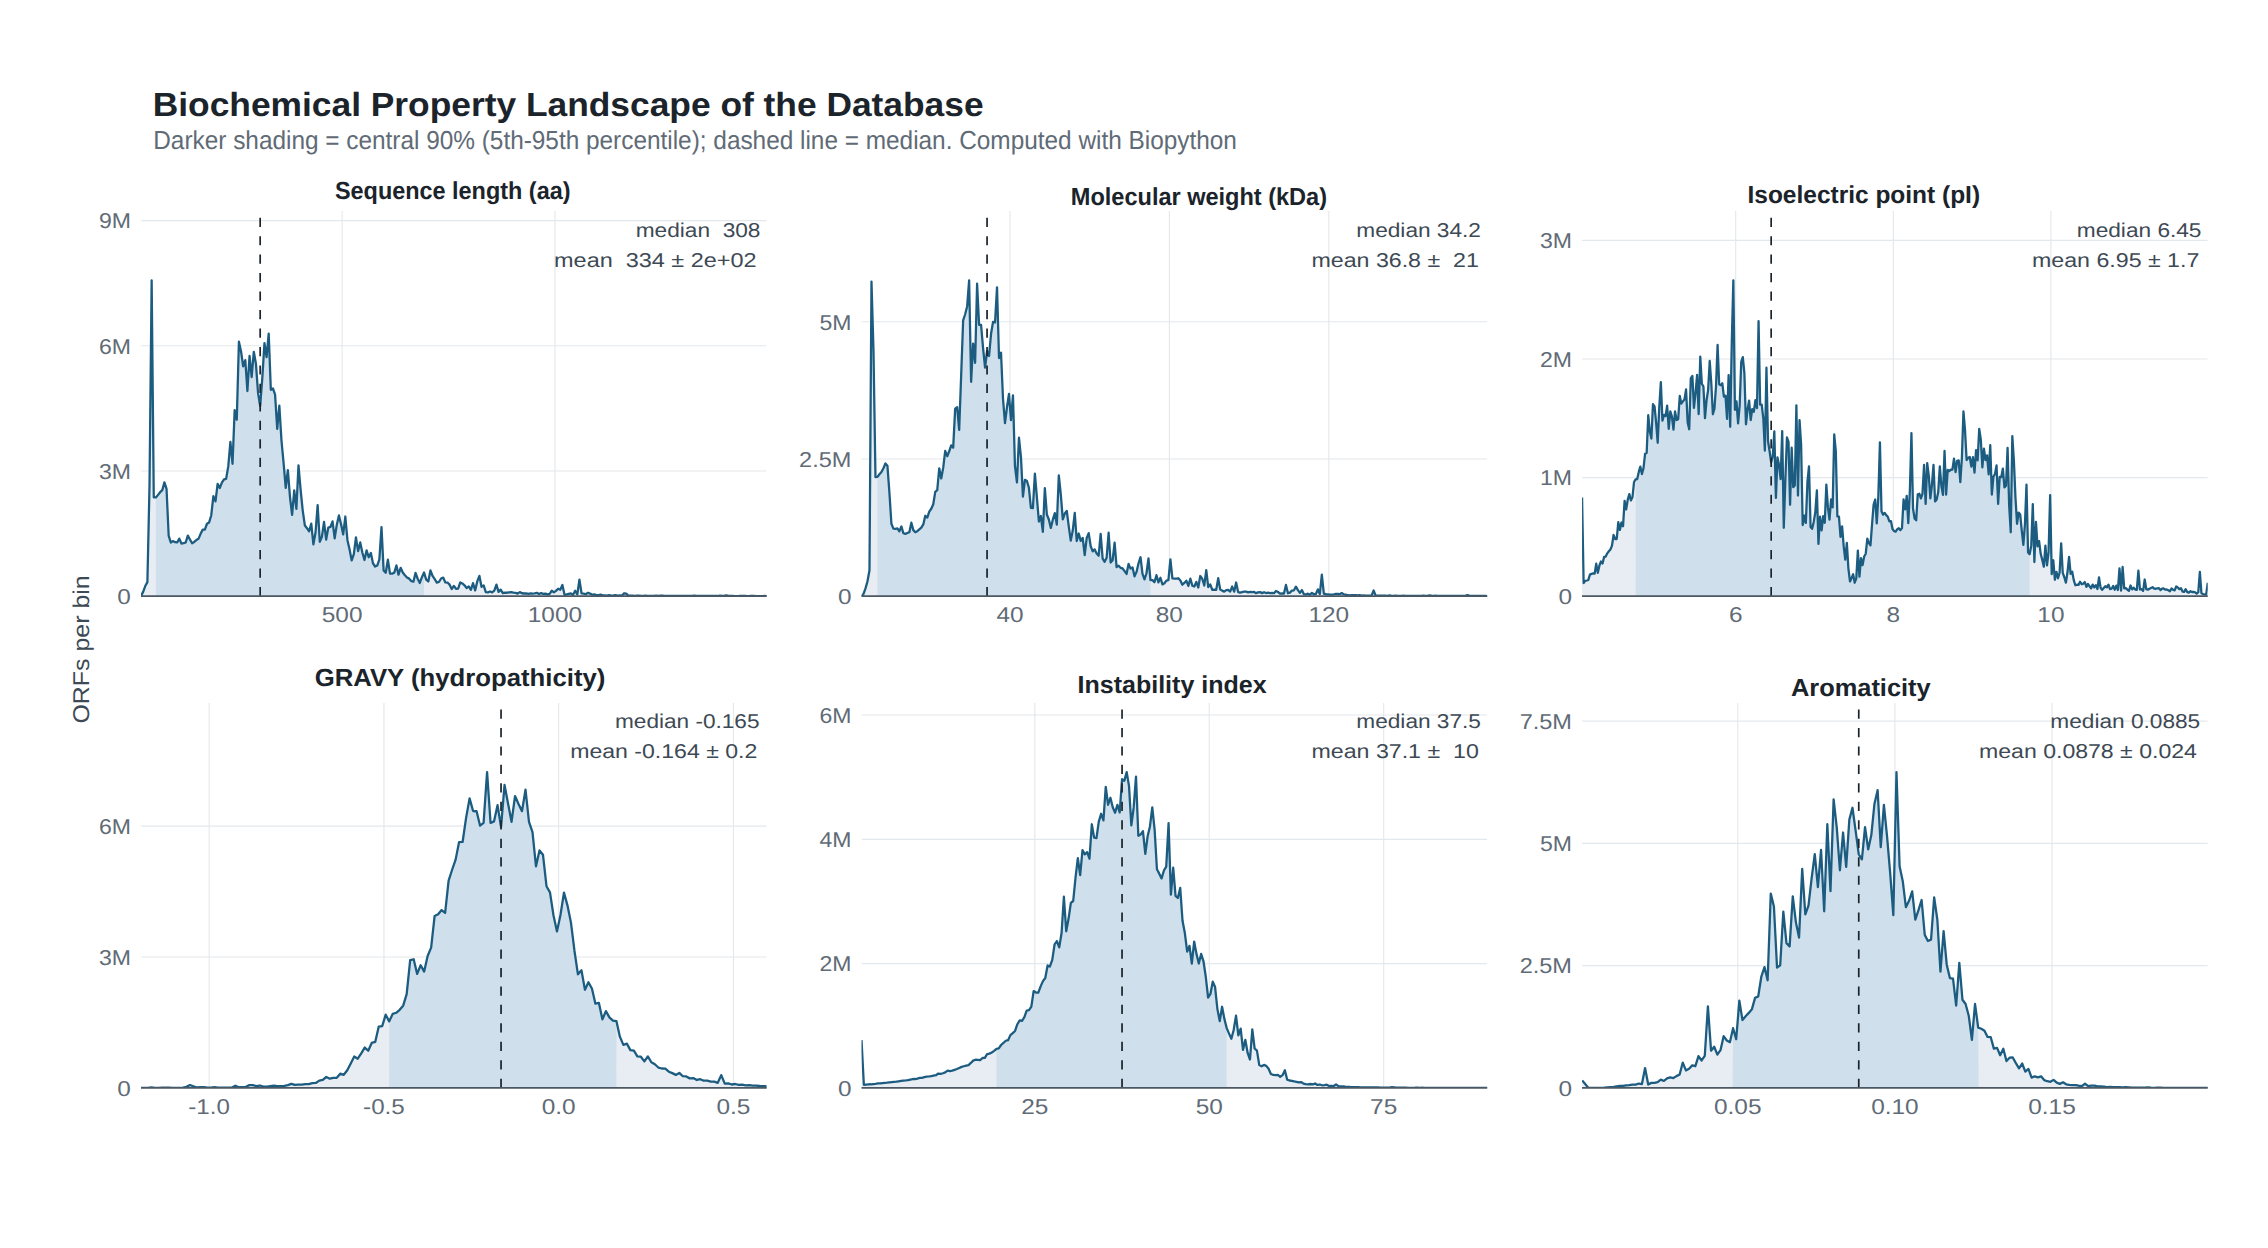

**Figure 6.** Distribution of each property across the database.
Shaded band = central 90% (5th–95th percentile); dashed line = median.

| Property | Median | Mean ± SD |
|---|---:|---:|
| Sequence length | 308 aa | 334 ± 195 |
| Molecular weight | 34.2 kDa | 36.8 ± 21.5 |
| Isoelectric point | 6.45 | 6.95 ± 1.71 |
| GRAVY | −0.165 | −0.164 ± 0.202 |
| Instability index | 37.5 | 37.1 ± 10.0 |
| Aromaticity | 0.0885 | 0.0878 ± 0.0236 |

The GRAVY score is centred slightly negative and near-symmetric and a strongly hydrophobic membrane means protein territory is sparsely populated. These values match the expectation for a corpus of globular soluble enzymes.

Isoelectric point is bimodal, with modes near pH 5.5 and pH 9 separated by a pronounced trough close to neutrality. This is usually attributed to proteins being under selection to
avoid minimum solubility at their working pH. Section 3.5 shows the trough is
independent of molecular weight, which argues against it being an artifact of
short sequences.

Median instability index is 37.5, just under the conventional threshold of
40 above which a protein is called unstable.

### 3.2. Effect of removing the signal peptide

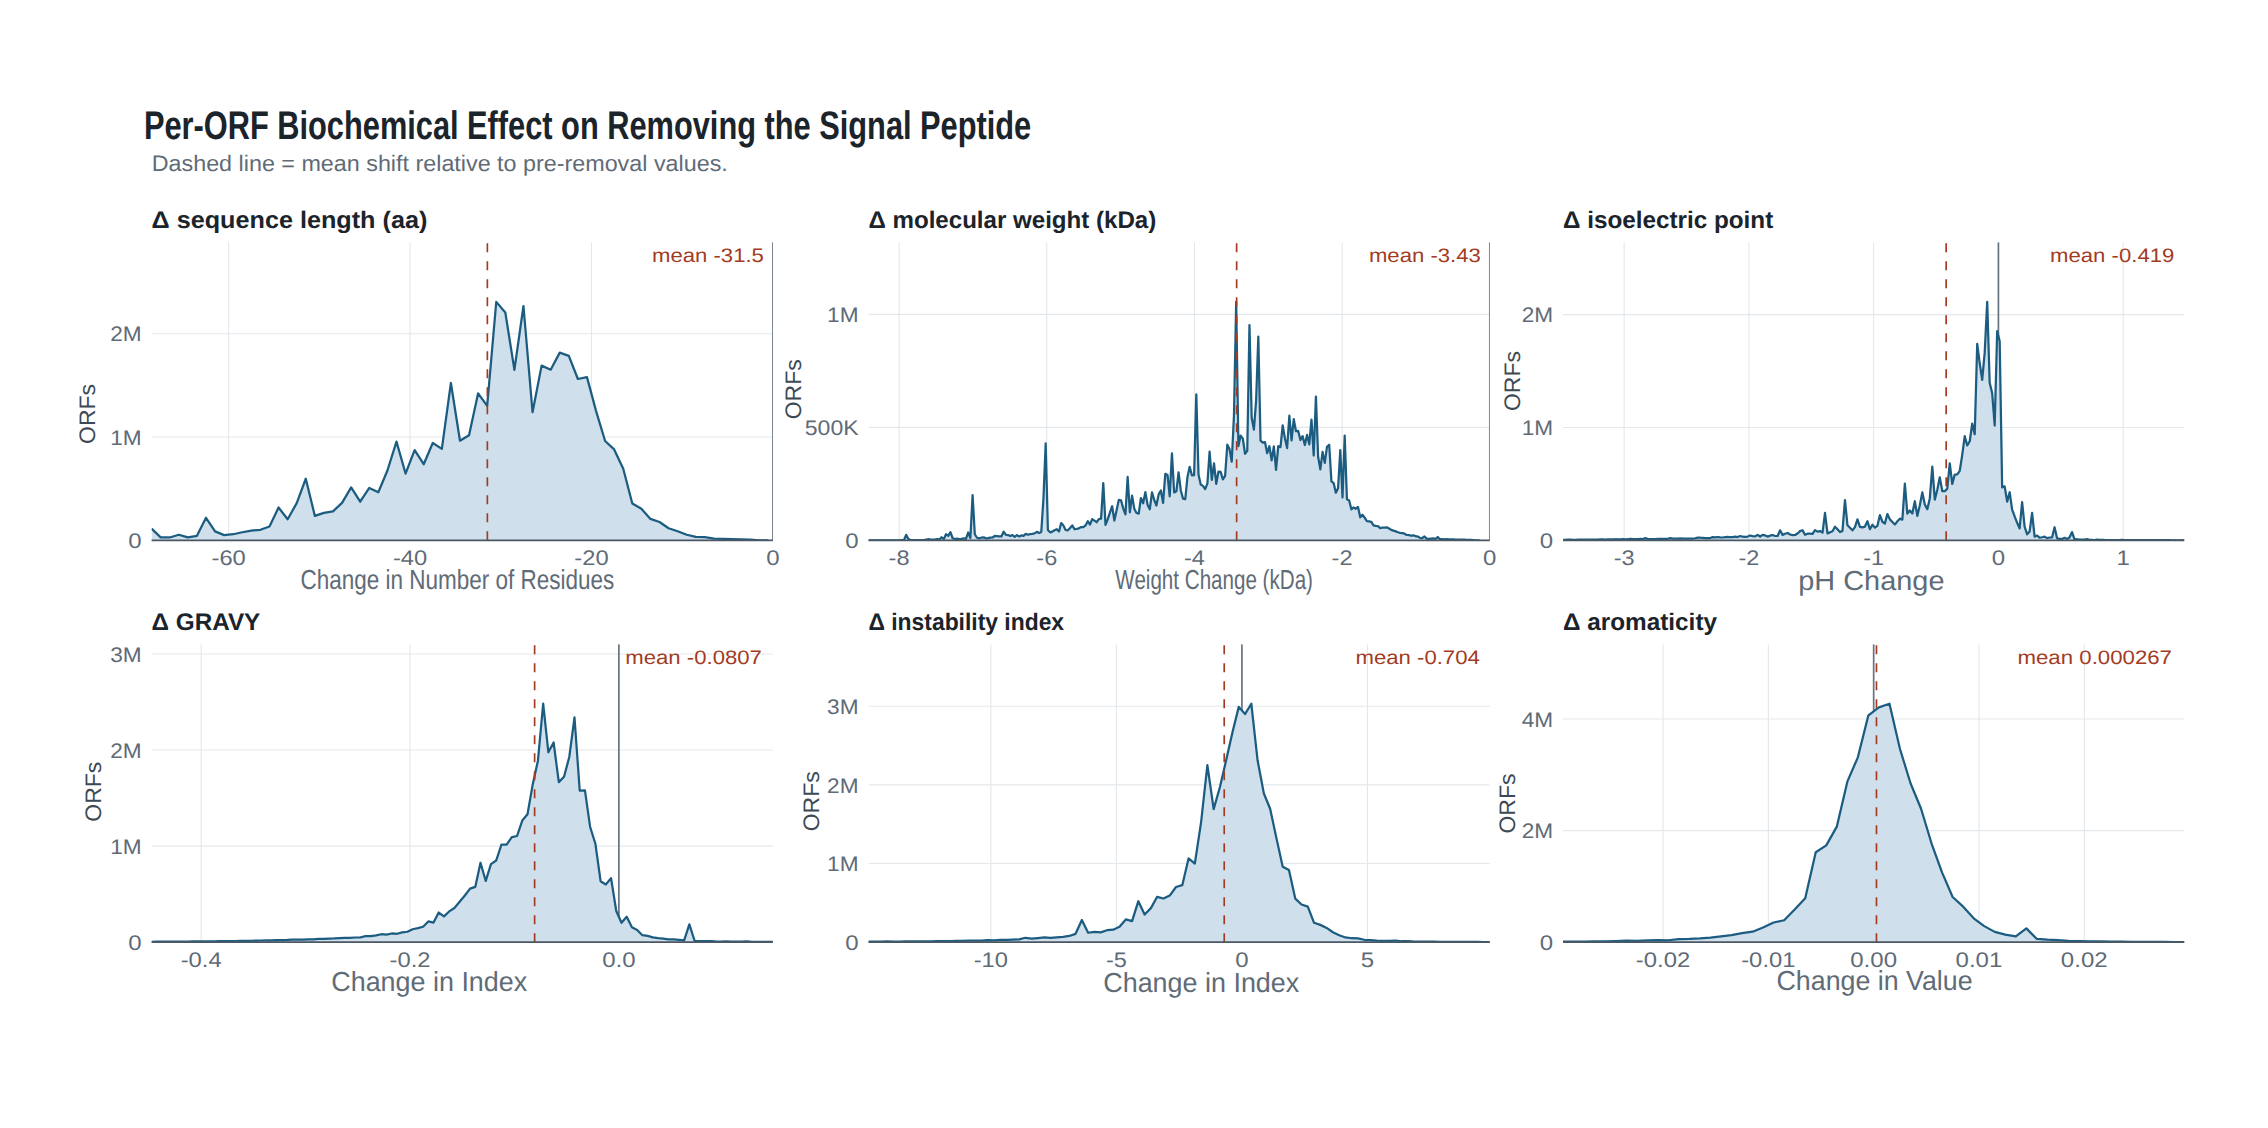

**Figure 7.** Per-ORF value change for the 42,522,234 secreted
ORFs when computed in cleaved and uncleaved forms. Dashed line = mean.

| Property | Mean shift | % of ORFs shifting negative |
|---|---:|---:|
| Sequence length | −31.5 aa | 100% (by construction) |
| Molecular weight | −3.43 kDa | 100% (by construction) |
| GRAVY | −0.0807 | 96.6% |
| Isoelectric point | −0.419 | 86.6% |
| Instability index | −0.704 | 58.2% |
| Aromaticity | +0.000267 | 45.2% |

The properties respond in a clear order.
GRAVY moves almost universally (96.6%) because the signal peptide's defining
feature is a hydrophobic h-region. pI follows at 86.6% because the n-region
carries positive charge. Instability index and aromaticity are close to an even split on positive or negative movement, which suggests no general patterns.

The shift is also route-dependent. For GRAVY:

| Class | Mean ΔGRAVY | n |
|---|---:|---:|
| SP (Sec/SPI) | −0.0866 | 32,942,214 |
| LIPO (Sec/SPII) | −0.0798 | 6,266,837 |
| TAT (Tat/SPI) | −0.0292 | 2,771,712 |
| TATLIPO (Tat/SPII) | +0.0074 | 541,261 |
| PILIN (Sec/SPIII) | +0.0361 | 210 |

SP and LIPO (both signal peptides for the Sec pathway) increase hydrophobicity, whereas the TAT pathways has smaller, more mixed contribution.

### 3.3. Properties by catalytic fold family

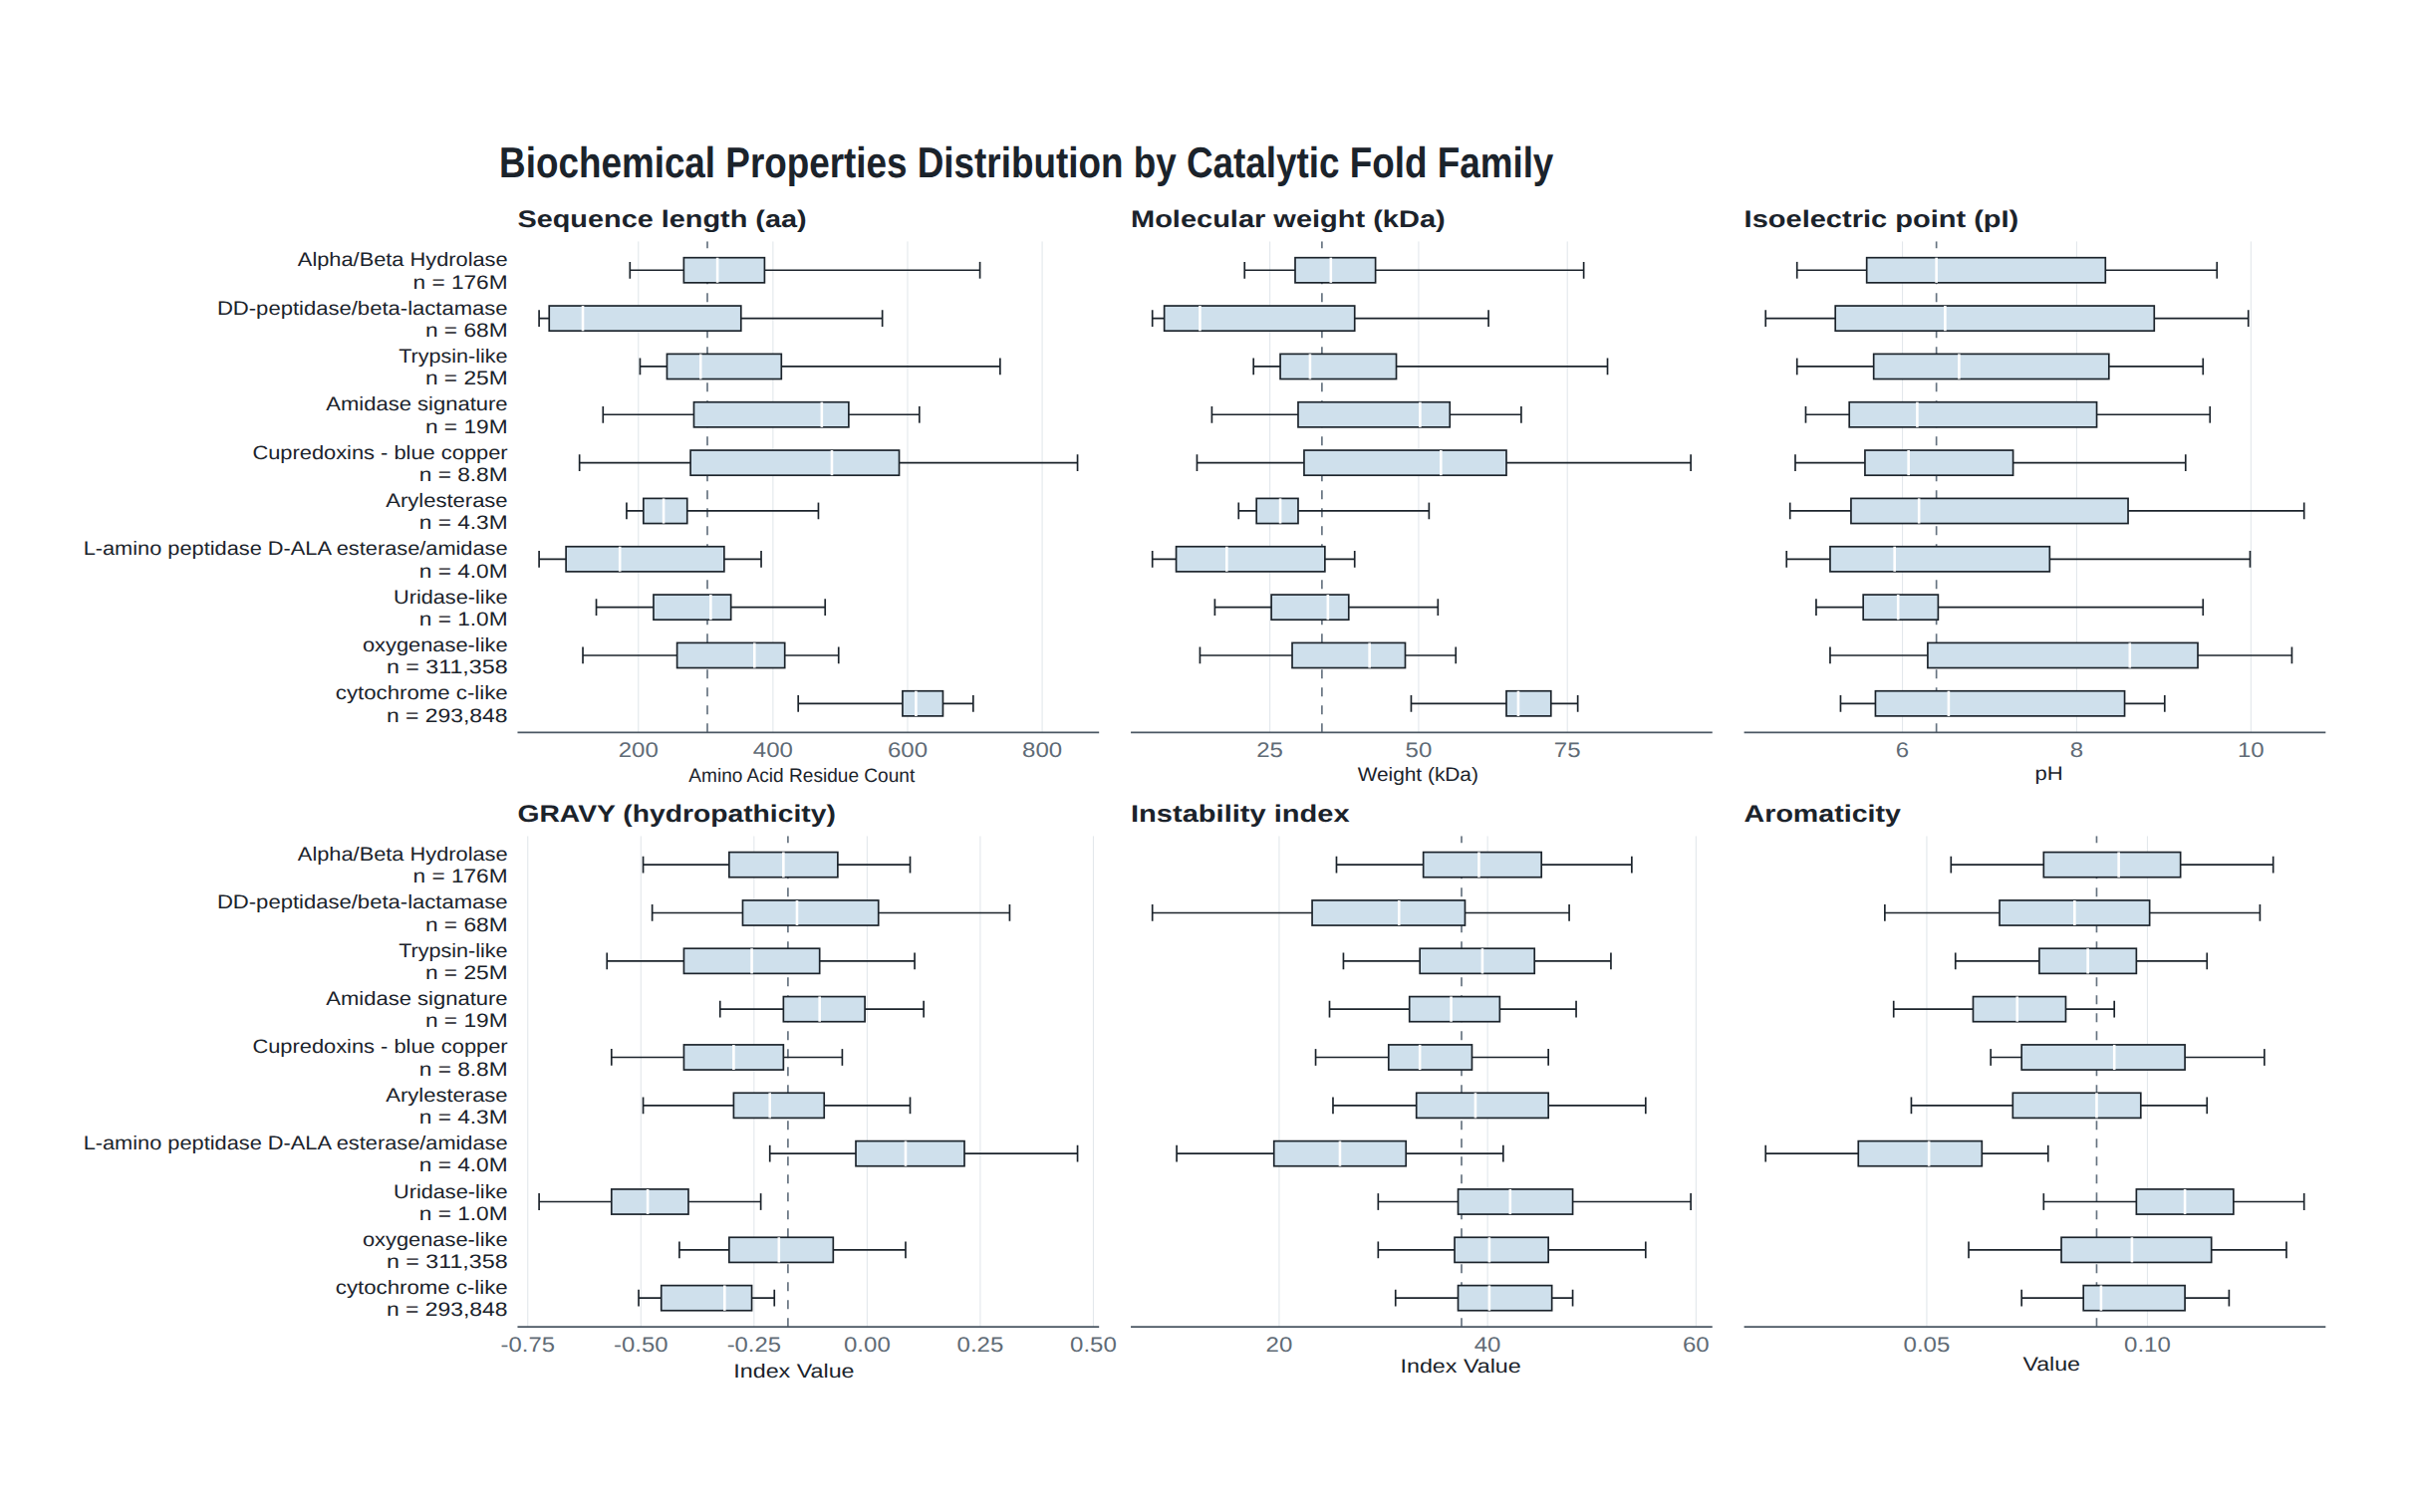

**Figure 8.** The distribution of the biochemical properties of all ORFs by their catalytic fold family. Box = interquartile range, white line =
median, whiskers = 5th–95th percentile. Dashed line = the database median.

Issue94 analyzes the same catalytic families for their relative abundance of secreted enzymes, which can be complemented with these result.

L-amino peptidase is the only family with positive median GRAVY, and it is
distinctive on three axes at once: most hydrophobic, lowest instability index,
and lowest aromaticity. It is also, from the SignalP results, the family with
the lowest secretion rate (1.2%). A hydrophobic, non-secreted family is
internally consistent.

That consistency extends across families. Cross-referencing family median
GRAVY against the secretion rates measured independently in the SignalP pipeline
gives a rank correlation of −0.96 (Spearman) — more hydrophilic families secrete more.

Furthermore, cytochrome c-like has by far the longest sequences (median near 600 aa against a database median of 308), and oxygenase-like is the only basic family (median pI 8.61 against 5.9–6.7 for every other family).

Nevertheless, a limitation to the results is that ProtParam computes properties from
sequence alone, assuming a fully folded soluble protein with no cofactors or
post-translational modification. Several of these families are defined by their
cofactors — cupredoxins bind copper, cytochrome c-like bind heme.

### 3.4. Properties by signal peptide class

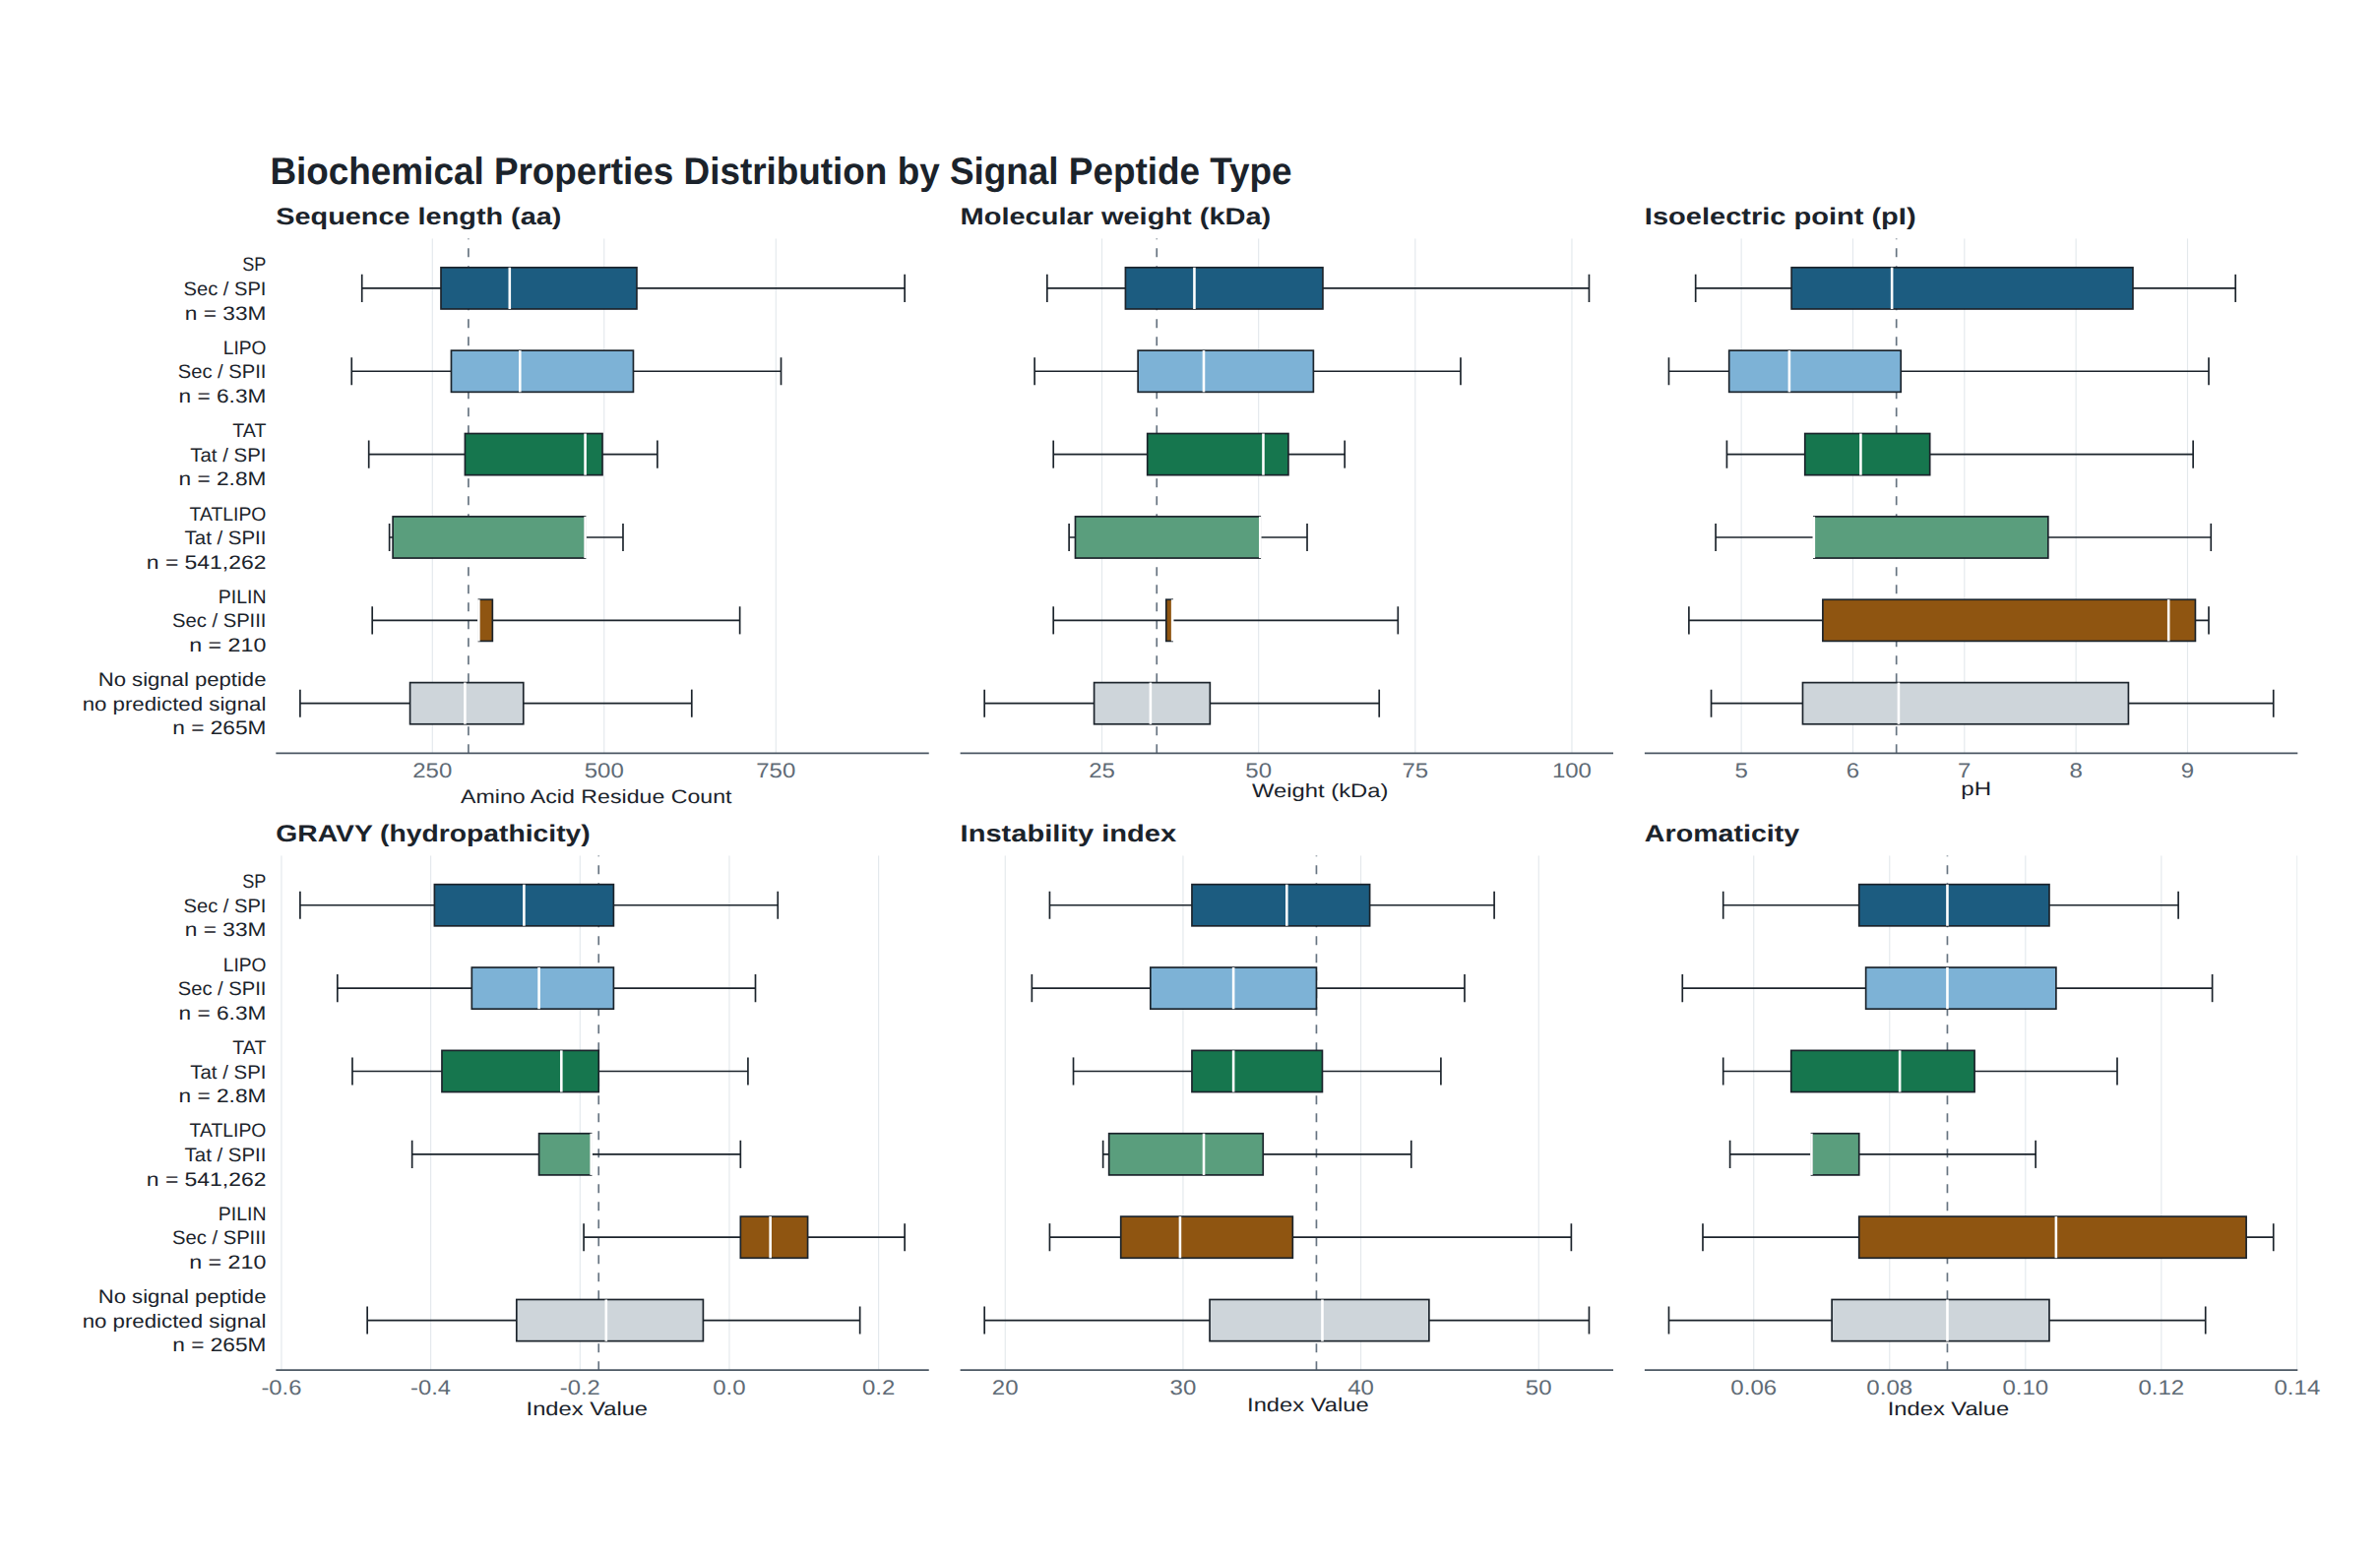

**Figure 9.** The distribution of the biochemical properties amongst the secreted ORFs, divided by signal peptide types.

| Class | n | Median GRAVY | IQR |
|---|---:|---:|---|
| SP | 32,942,387 | −0.275 | [−0.395, −0.155] |
| LIPO | 6,266,863 | −0.255 | [−0.345, −0.155] |
| TAT | 2,771,736 | −0.225 | [−0.385, −0.175] |
| TATLIPO | 541,262 | −0.185 | [−0.255, −0.185] |
| PILIN | 210 | +0.055 | [+0.015, +0.105] |
| **No signal peptide** | **264,614,829** | **−0.165** | [−0.285, −0.035] |

The ordering within the secreted classes mirrors the ΔGRAVY ordering
in 3.2: Sec-routed classes sit furthest from the non-secreted median, Tat-routed
classes closer.

Secreted ORFs are also longer (SP median 367 aa mature, against 297 aa for
non-secreted) and slightly more acidic.

PILIN is drawn for completeness and is the only class with positive median
GRAVY but should not be overinterpretted given its very small sample size.

### 3.5. Property pairs

Pairs of biochemical properties were also graphed together per-ORF to reveal any patterns, and heat maps for both the full database and the secreted subset are shown.

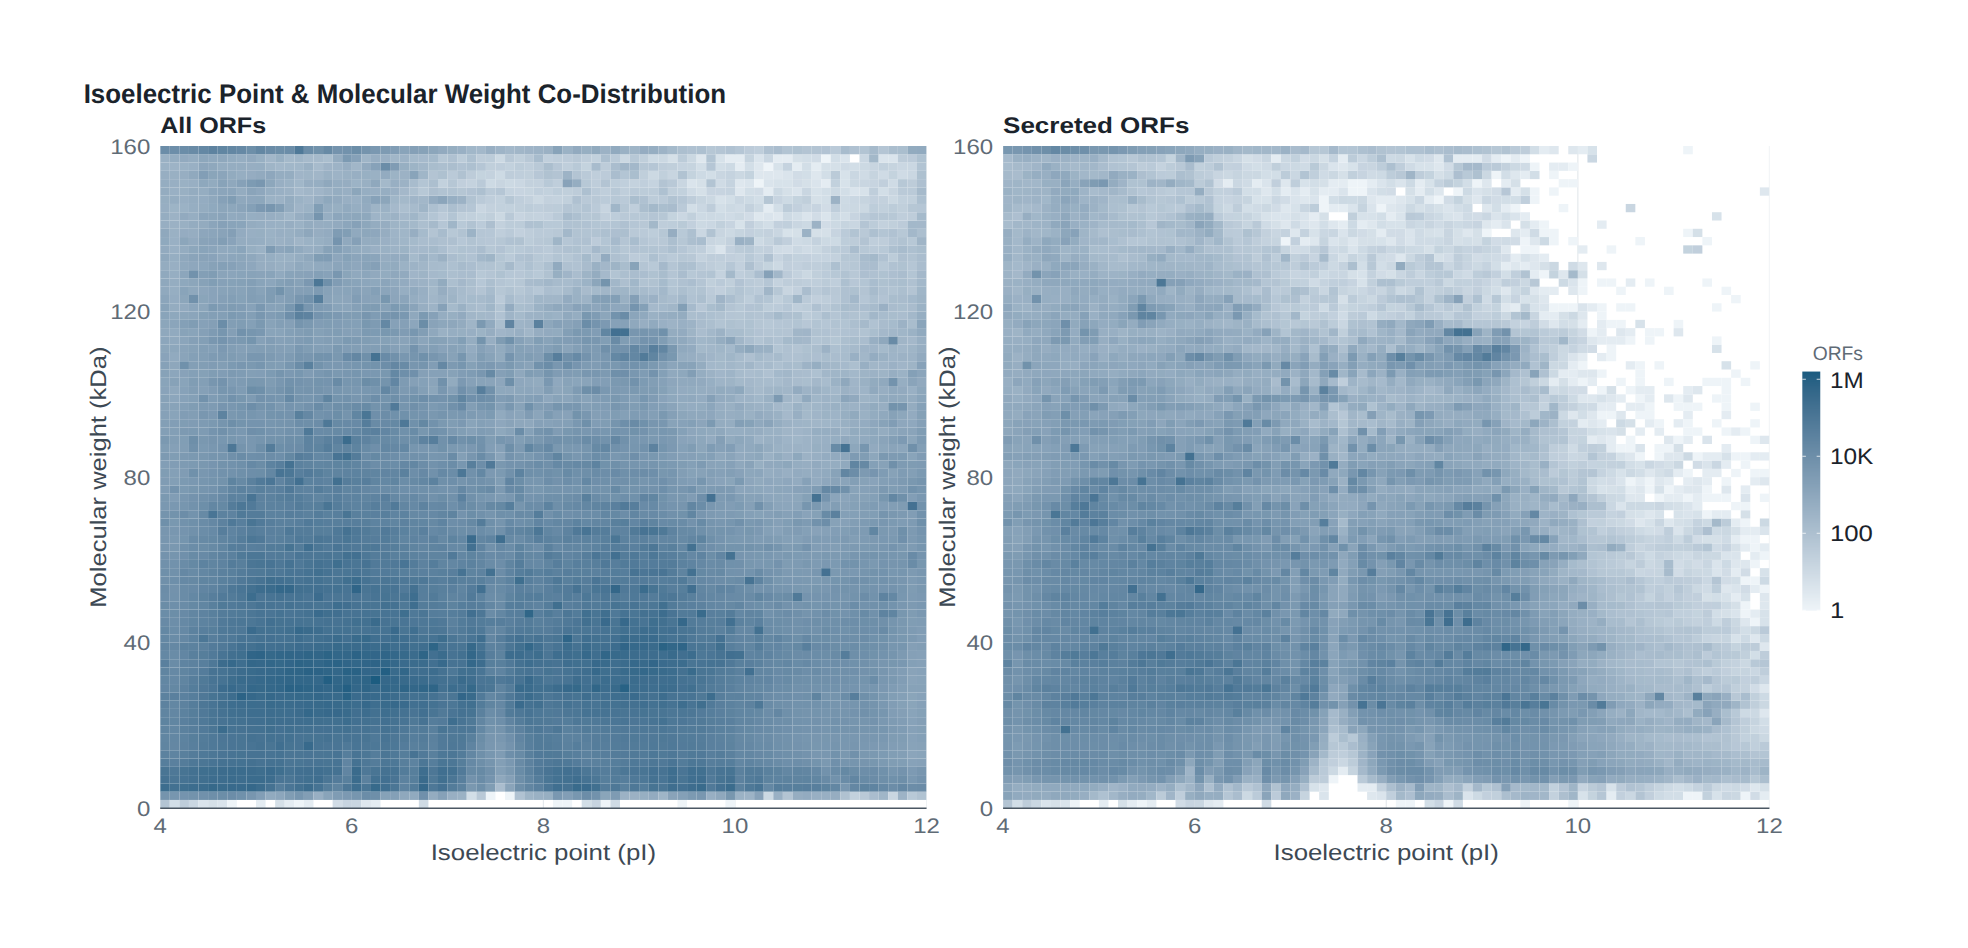

**Figure 10.** Isoelectric point against molecular weight, which forms the axes a 2D gel
(isoelectric focusing × SDS-PAGE) separates on.

The pI bimodality from 3.1 appears here as a vertical depletion band near
pH 7.4 that runs the full height of the panel.

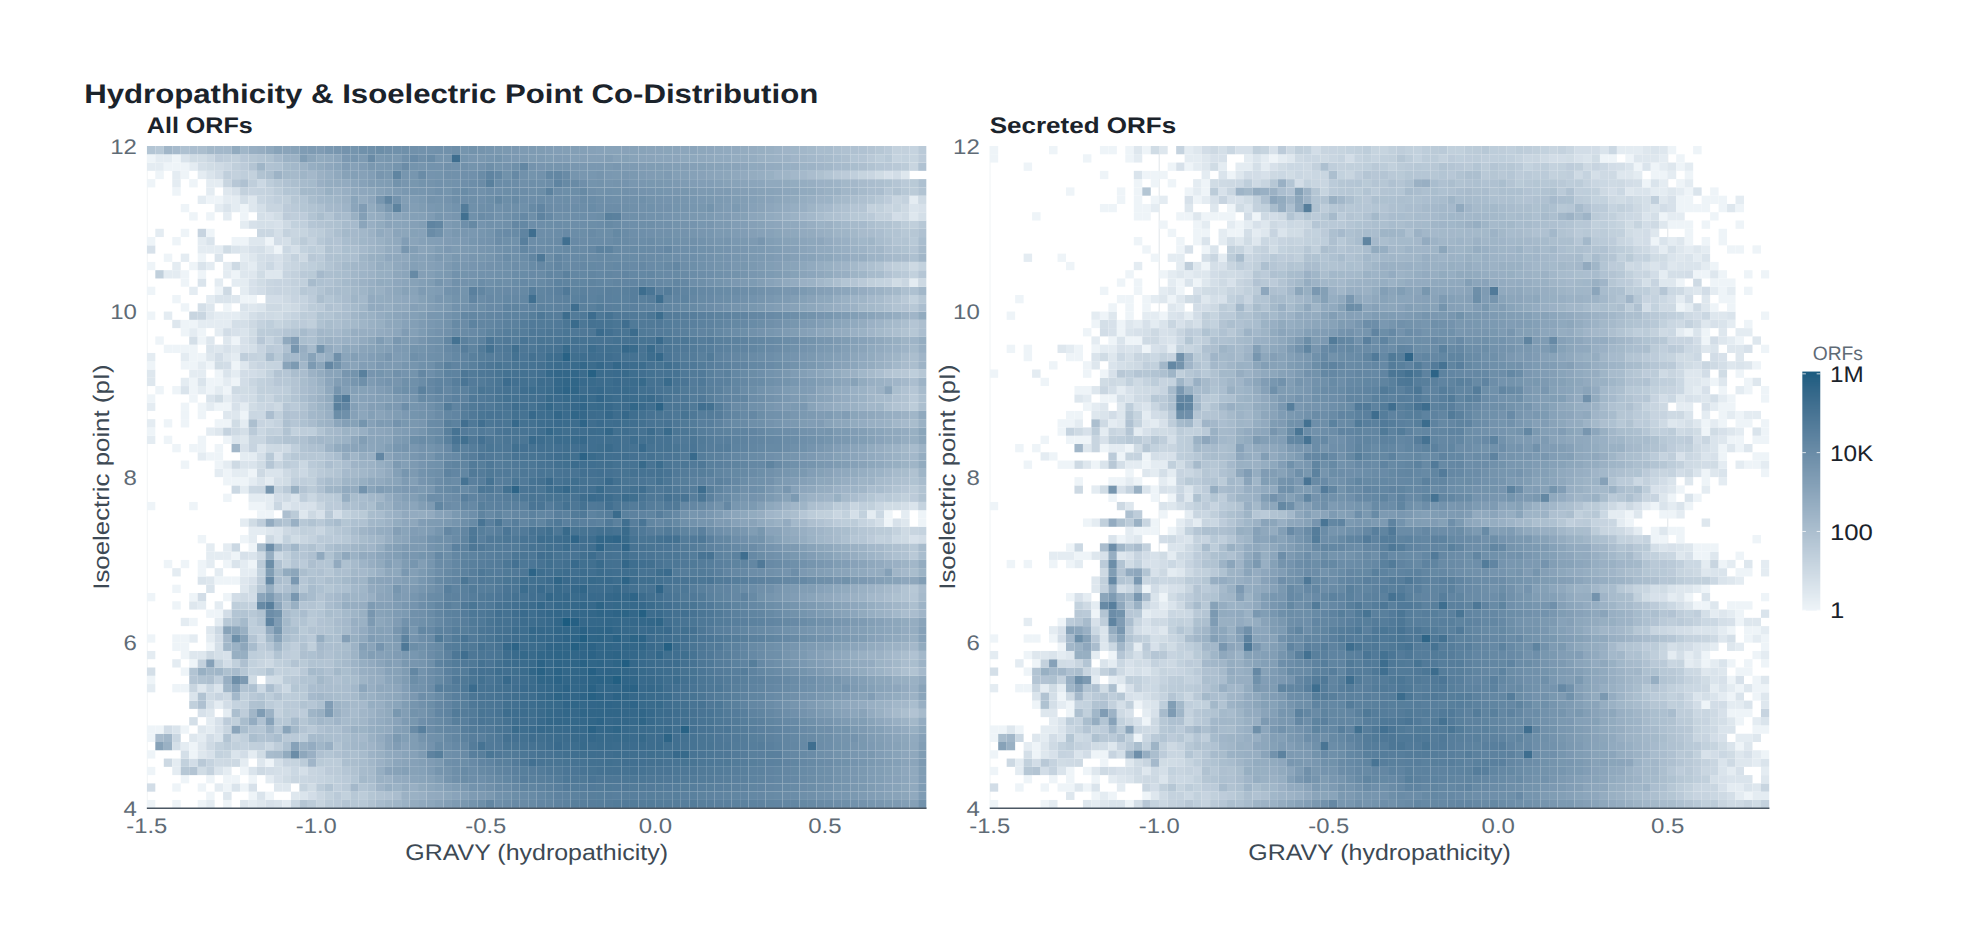

**Figure 11.** Hydropathicity against isoelectric point, which forms a promising plane to triage candidates for recombinant expression.

The same pH 7.4 depletion appears as a horizontal band. Comparing panels, the
secreted cloud sits visibly left of the all-ORF cloud: the same shift quantified
in 3.2, seen as a displacement of the whole population rather than a difference
of means.

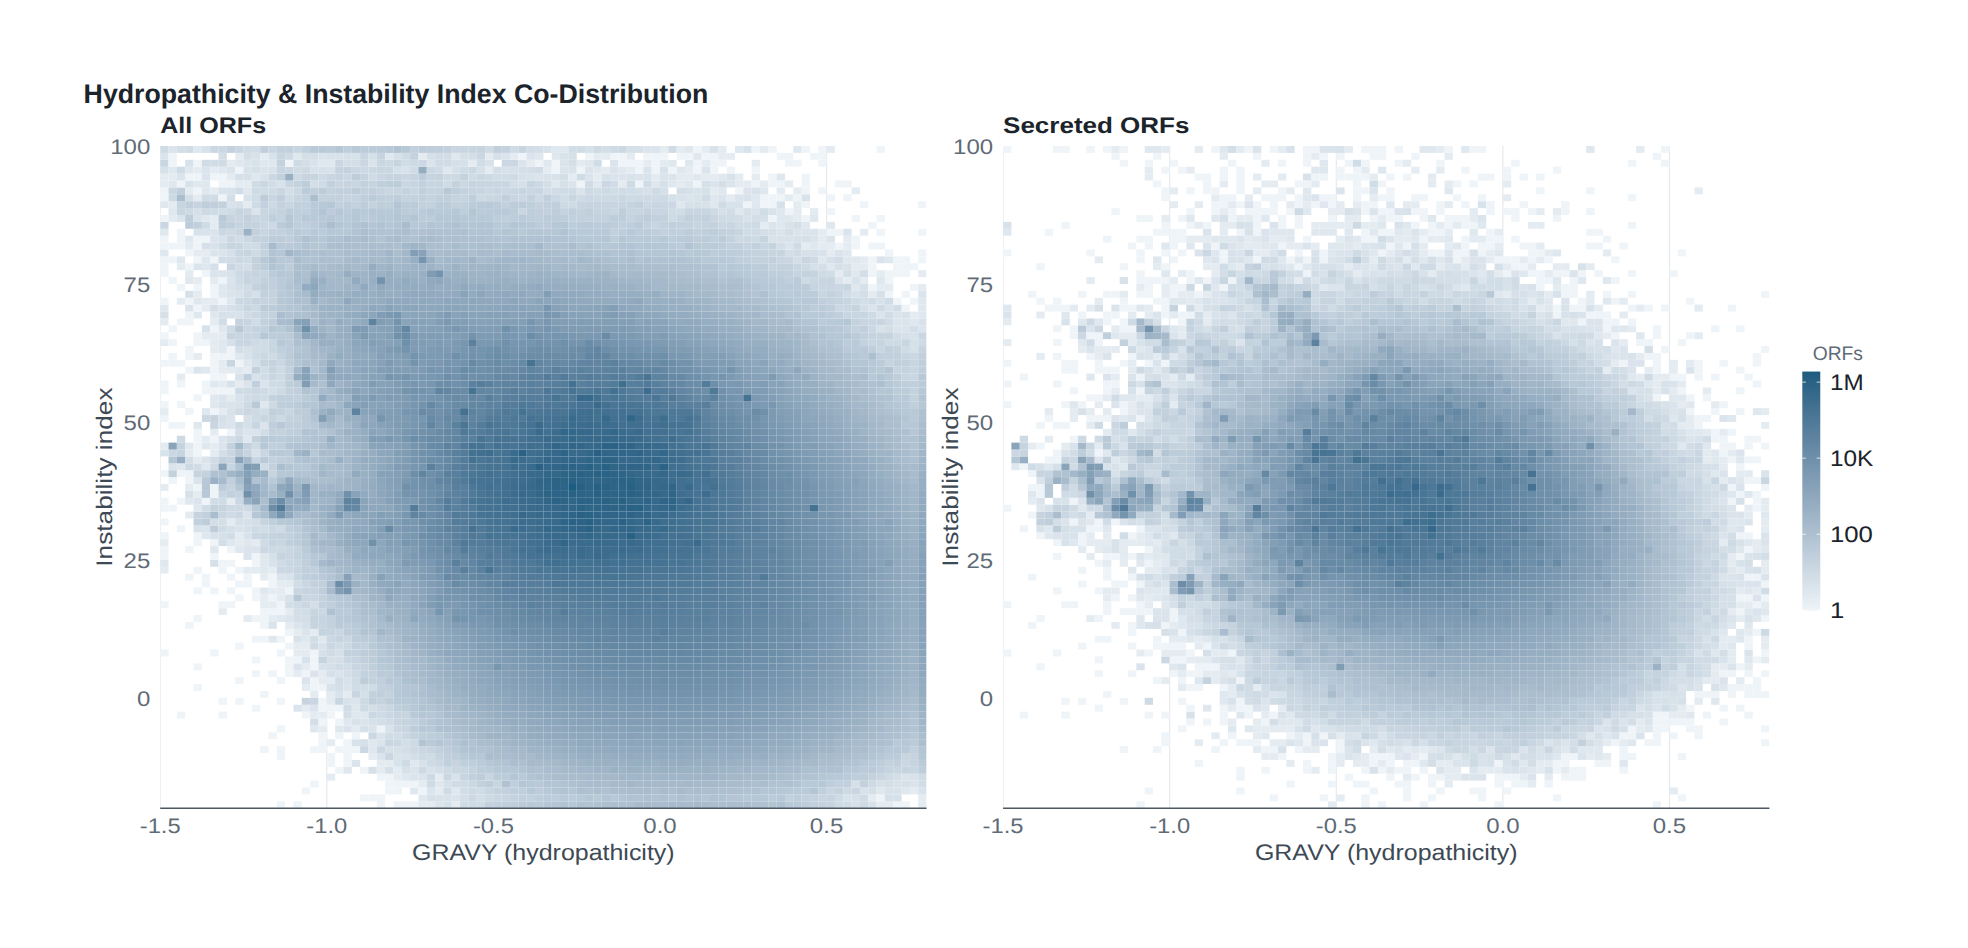

**Figure 12.** Hydropathicity against instability index — two ProtParam-derived
expression-feasibility proxies.

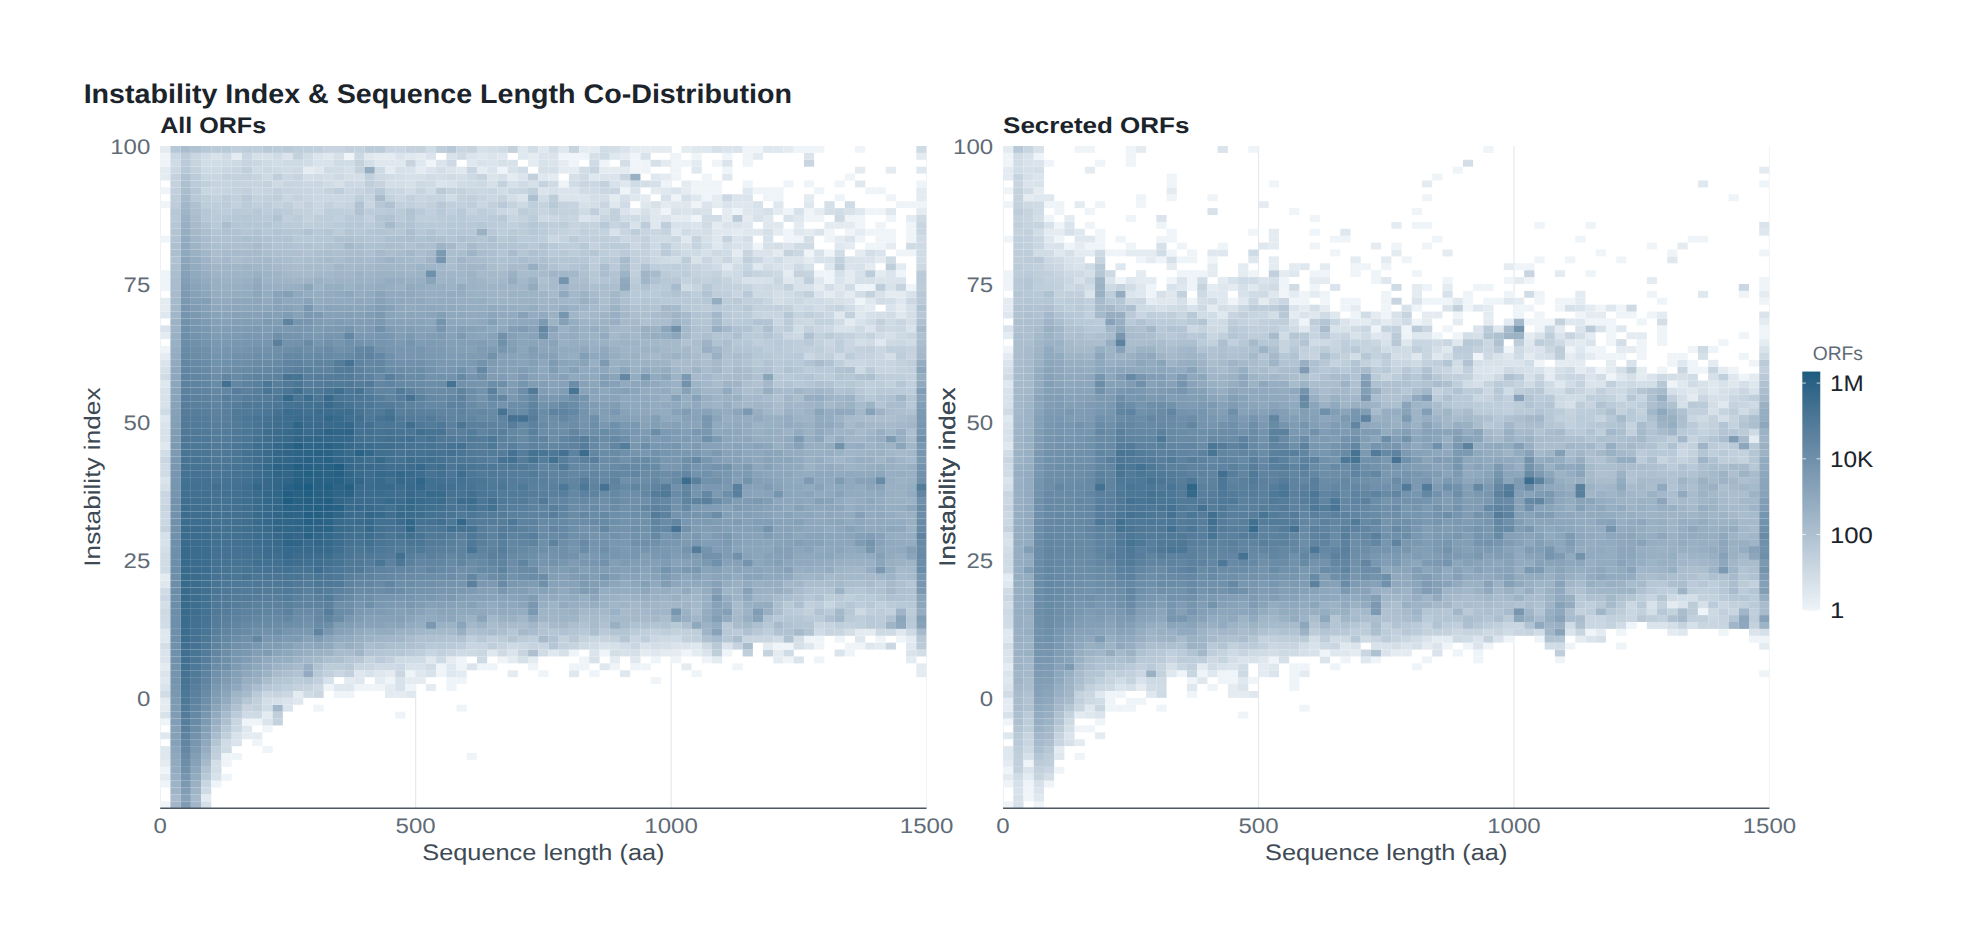

**Figure 13.** Instability index against sequence length, which acts as
a quality check.

The lower boundary of the distribution sweeps upward with length: negative values are confined almost entirely to sequences below roughly 100 aa, and the spread narrows steadily as
length increases. The 721,289 negative values of the database (0.23%) are therefore a formula artifact of short sequences.

------------------------------------------------------------------------

## Appendix: Pipeline Scripts

### A. `precompute_biochem_resumable.py`

Streams the ORF FASTA record by record, computes ProtParam properties on the
full translated sequence, and writes resumable gzip-compressed CSV parts.

```python
#!/usr/bin/env python3

import argparse
import csv
import gzip
import json
import math
import os
import re
import sys
import time
from pathlib import Path
from Bio.SeqUtils.ProtParam import ProteinAnalysis

STANDARD_AA = set("ACDEFGHIKLMNPQRSTVWY")
HEADER_RE = re.compile(r"^>(\S+)")

COLUMNS = [
    "orf_id",
    "sequence_length",
    "molecular_weight",
    "isoelectric_point",
    "gravy_score",
    "instability_index",
    "aromaticity",
    "calc_status",
    "noncanonical_residues",
]

def parse_orf_id(header_line: str) -> int:
    """
    PETaDex header:
    >{orf_id}|{genbank_accession}|{library_id}|{contig_id}|{orf_start}|{orf_end}|{orf_type}
    """
    m = HEADER_RE.match(header_line.strip())
    if not m:
        raise ValueError(f"Bad FASTA header: {header_line[:120]}")

    first_token = m.group(1)
    orf_id_text = first_token.split("|", 1)[0]
    return int(orf_id_text)

def clean_seq(seq: str):
    seq = seq.strip().upper().replace("*", "")
    invalid = sorted(set(seq) - STANDARD_AA)
    return seq, invalid

def compute_props(seq: str):
    p = ProteinAnalysis(seq)
    return {
        "sequence_length": len(seq),
        "molecular_weight": p.molecular_weight(),
        "isoelectric_point": p.isoelectric_point(),
        "gravy_score": p.gravy(),
        "instability_index": p.instability_index(),
        "aromaticity": p.aromaticity(),
    }

def fmt_float(x):
    if x is None:
        return r"\N"
    if isinstance(x, float) and (math.isnan(x) or math.isinf(x)):
        return r"\N"
    return f"{x:.6f}"

def fasta_records(path: Path):
    with path.open("rt", encoding="utf-8", errors="replace") as handle:
        header = None
        chunks = []

        for line in handle:
            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(chunks)
                header = line.rstrip("\n")
                chunks = []
            else:
                chunks.append(line.strip())

        if header is not None:
            yield header, "".join(chunks)

def load_manifest(manifest_path: Path):
    if manifest_path.exists():
        with manifest_path.open("rt") as f:
            return json.load(f)
    return None

def save_manifest(manifest_path: Path, manifest: dict):
    tmp_path = manifest_path.with_suffix(".json.tmp")
    with tmp_path.open("wt") as f:
        json.dump(manifest, f, indent=2)
    tmp_path.replace(manifest_path)

def write_part(out_dir: Path, part_index: int, rows):
    parts_dir = out_dir / "parts"
    parts_dir.mkdir(parents=True, exist_ok=True)

    final_path = parts_dir / f"orf_biochem_part_{part_index:06d}.csv.gz"
    tmp_path = parts_dir / f"orf_biochem_part_{part_index:06d}.csv.gz.tmp"

    if final_path.exists():
        return final_path

    with gzip.open(tmp_path, "wt", newline="") as fh:
        writer = csv.writer(fh)
        writer.writerow(COLUMNS)
        writer.writerows(rows)

    tmp_path.replace(final_path)
    return final_path

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--fasta", required=True)
    ap.add_argument("--out-dir", required=True)
    ap.add_argument("--rows-per-file", type=int, default=5_000_000)
    ap.add_argument("--progress-every", type=int, default=100_000)
    ap.add_argument("--max-records", type=int, default=None)
    ap.add_argument("--resume", action="store_true")
    args = ap.parse_args()

    fasta_path = Path(args.fasta)
    out_dir = Path(args.out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    parts_dir = out_dir / "parts"
    parts_dir.mkdir(exist_ok=True)

    manifest_path = out_dir / "manifest.json"
    bad_path = out_dir / "bad_records.tsv"

    # Clean abandoned temp files from interrupted runs.
    for tmp in parts_dir.glob("*.tmp"):
        tmp.unlink()

    old_manifest = load_manifest(manifest_path) if args.resume else None
    completed_rows = int(old_manifest.get("rows_written", 0)) if old_manifest else 0
    completed_parts = int(old_manifest.get("files_written", 0)) if old_manifest else 0

    stats = {
        "source_fasta": str(fasta_path),
        "rows_per_file": args.rows_per_file,
        "records_seen_total_this_run": 0,
        "records_skipped_due_to_resume": completed_rows,
        "rows_written": completed_rows,
        "ok_rows": int(old_manifest.get("ok_rows", 0)) if old_manifest else 0,
        "invalid_sequence_rows": int(old_manifest.get("invalid_sequence_rows", 0)) if old_manifest else 0,
        "parse_error_rows": int(old_manifest.get("parse_error_rows", 0)) if old_manifest else 0,
        "files_written": completed_parts,
        "start_time": time.time(),
        "resume": bool(old_manifest),
    }

    print(f"[start] fasta={fasta_path}", flush=True)
    print(f"[start] out_dir={out_dir}", flush=True)
    print(f"[start] resume={bool(old_manifest)} completed_rows={completed_rows:,}", flush=True)

    if not bad_path.exists() or not old_manifest:
        with bad_path.open("wt") as bad:
            bad.write("reason\theader\tdetails\n")

    current_rows = []
    part_index = completed_parts

    processed_index = 0

    with bad_path.open("at") as bad:
        for header, seq_raw in fasta_records(fasta_path):
            if args.max_records is not None and processed_index >= args.max_records:
                break

            processed_index += 1
            stats["records_seen_total_this_run"] += 1

            if processed_index <= completed_rows:
                if processed_index % args.progress_every == 0:
                    print(f"[resume-skip] skipped={processed_index:,}/{completed_rows:,}", flush=True)
                continue

            try:
                orf_id = parse_orf_id(header)
                seq, invalid = clean_seq(seq_raw)

                if len(seq) == 0:
                    raise ValueError("empty_sequence")

                if invalid:
                    row = [
                        orf_id,
                        len(seq),
                        r"\N",
                        r"\N",
                        r"\N",
                        r"\N",
                        r"\N",
                        "invalid_sequence",
                        "".join(invalid),
                    ]
                    stats["invalid_sequence_rows"] += 1
                else:
                    props = compute_props(seq)
                    row = [
                        orf_id,
                        props["sequence_length"],
                        fmt_float(props["molecular_weight"]),
                        fmt_float(props["isoelectric_point"]),
                        fmt_float(props["gravy_score"]),
                        fmt_float(props["instability_index"]),
                        fmt_float(props["aromaticity"]),
                        "ok",
                        "",
                    ]
                    stats["ok_rows"] += 1

                current_rows.append(row)
                stats["rows_written"] += 1

            except Exception as e:
                stats["parse_error_rows"] += 1
                safe_header = header.replace("\t", " ")[:300]
                bad.write(f"parse_error\t{safe_header}\t{repr(e)}\n")

            if len(current_rows) >= args.rows_per_file:
                final_path = write_part(out_dir, part_index, current_rows)
                part_index += 1
                current_rows = []

                stats["files_written"] = part_index
                stats["elapsed_sec"] = time.time() - stats["start_time"]
                stats["records_per_sec_this_run"] = stats["records_seen_total_this_run"] / stats["elapsed_sec"] if stats["elapsed_sec"] else None
                save_manifest(manifest_path, stats)

                print(
                    f"[part-complete] {final_path} "
                    f"rows_written={stats['rows_written']:,} "
                    f"ok={stats['ok_rows']:,} "
                    f"invalid={stats['invalid_sequence_rows']:,} "
                    f"errors={stats['parse_error_rows']:,}",
                    flush=True,
                )

            if processed_index % args.progress_every == 0:
                elapsed = time.time() - stats["start_time"]
                rate = stats["records_seen_total_this_run"] / elapsed if elapsed else 0
                print(
                    f"[progress] records_seen_this_run={stats['records_seen_total_this_run']:,} "
                    f"global_position={processed_index:,} "
                    f"rows_written={stats['rows_written']:,} "
                    f"rate_this_run={rate:,.1f}/sec",
                    flush=True,
                )

    if current_rows:
        final_path = write_part(out_dir, part_index, current_rows)
        part_index += 1
        stats["files_written"] = part_index
        print(f"[final-part-complete] {final_path}", flush=True)

    stats["elapsed_sec"] = time.time() - stats["start_time"]
    stats["records_per_sec_this_run"] = stats["records_seen_total_this_run"] / stats["elapsed_sec"] if stats["elapsed_sec"] else None
    stats["completed"] = True
    save_manifest(manifest_path, stats)

    print("[complete]", flush=True)
    print(json.dumps(stats, indent=2), flush=True)

if __name__ == "__main__":
    main()
```

> **Note on the archived output.** The copy of this script that produced the
> 2026-07-06 run emitted two further columns that were never implemented (null
> in all 307,155,746 rows). They are omitted from the listing above and
> excluded at load time (2.7); the archived CSVs on S3 retain them, so the
> column selection in the load command is required rather than cosmetic.
>
> Note also that this pass checkpoints on rows written, which is correct only
> because every record produces exactly one row. The mature pass (Appendix B)
> cannot use that assumption and checkpoints on FASTA record position instead.

### B. `precompute_biochem_mature.py`

Streams the same FASTA, looks up each ORF's SignalP cleavage site via the
exported Signalp TSV, computes ProtParam properties on the mature slice, and
writes resumable gzip-compressed CSV parts containing only ORFs with a usable
cleavage position.

```python
#!/usr/bin/env python3

import argparse
import csv
import gzip
import io
import json
import math
import re
import time
from pathlib import Path
from urllib.parse import urlparse

import boto3
import numpy as np
from Bio.SeqUtils.ProtParam import ProteinAnalysis

STANDARD_AA = set("ACDEFGHIKLMNPQRSTVWY")
HEADER_RE = re.compile(r"^>(\S+)")

COLUMNS = [
    "orf_id",
    "mature_cleavage_pos",
    "mature_molecular_weight",
    "mature_isoelectric_point",
    "mature_gravy_score",
    "mature_instability_index",
    "mature_aromaticity",
]


def parse_orf_id(header_line: str) -> int:
    """
    PETaDex header:
    >{orf_id}|{genbank_accession}|{library_id}|{contig_id}|{orf_start}|{orf_end}|{orf_type}
    """
    m = HEADER_RE.match(header_line.strip())
    if not m:
        raise ValueError(f"Bad FASTA header: {header_line[:120]}")
    return int(m.group(1).split("|", 1)[0])


def load_cleavage_lookup(path):
    """
    Load a two-column TSV (orf_id, cleavage_pos) exported from
    signalp6_orf_predictions into two parallel, orf_id-sorted NumPy arrays.

    At ~42.5M rows this is roughly 340 MB, versus several GB for a Python dict
    of boxed ints. Lookup is O(log n) via numpy.searchsorted.
    """
    orf_ids = []
    positions = []
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rt", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter="\t")
        for row in reader:
            orf_ids.append(int(row["orf_id"]))
            positions.append(int(row["cleavage_pos"]))

    orf_id_arr = np.asarray(orf_ids, dtype=np.int64)
    pos_arr = np.asarray(positions, dtype=np.int32)
    order = np.argsort(orf_id_arr, kind="stable")
    return orf_id_arr[order], pos_arr[order]


def lookup_cleavage_pos(orf_id_arr, pos_arr, orf_id: int):
    idx = np.searchsorted(orf_id_arr, orf_id)
    if idx < len(orf_id_arr) and orf_id_arr[idx] == orf_id:
        return int(pos_arr[idx])
    return None


def clean_full_sequence(seq_raw: str) -> str:
    """Uppercase and strip terminal stop symbols, establishing the same residue
    coordinate system SignalP itself used, before slicing."""
    return seq_raw.strip().upper().replace("*", "")


def fmt_float(x):
    if x is None or (isinstance(x, float) and (math.isnan(x) or math.isinf(x))):
        return r"\N"
    return f"{x:.6f}"


def open_fasta_stream(source: str):
    """Open a FASTA source as a text-mode line iterator. Supports local paths
    and s3:// URIs (streamed, not downloaded)."""
    if source.startswith("s3://"):
        parsed = urlparse(source)
        s3 = boto3.client("s3")
        obj = s3.get_object(Bucket=parsed.netloc, Key=parsed.path.lstrip("/"))
        return io.TextIOWrapper(obj["Body"], encoding="utf-8", errors="replace")
    return open(source, "rt", encoding="utf-8", errors="replace")


def fasta_records(source: str):
    handle = open_fasta_stream(source)
    try:
        header = None
        chunks = []
        for line in handle:
            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(chunks)
                header = line.rstrip("\n")
                chunks = []
            else:
                chunks.append(line.strip())
        if header is not None:
            yield header, "".join(chunks)
    finally:
        handle.close()


def load_manifest(manifest_path: Path):
    if manifest_path.exists():
        with manifest_path.open("rt") as f:
            return json.load(f)
    return None


def save_manifest(manifest_path: Path, manifest: dict):
    tmp_path = manifest_path.with_suffix(".json.tmp")
    with tmp_path.open("wt") as f:
        json.dump(manifest, f, indent=2)
    tmp_path.replace(manifest_path)


def write_part(out_dir: Path, part_index: int, rows):
    parts_dir = out_dir / "parts"
    parts_dir.mkdir(parents=True, exist_ok=True)

    final_path = parts_dir / f"orf_mature_part_{part_index:06d}.csv.gz"
    tmp_path = parts_dir / f"orf_mature_part_{part_index:06d}.csv.gz.tmp"

    if final_path.exists():
        return final_path

    with gzip.open(tmp_path, "wt", newline="") as fh:
        writer = csv.writer(fh)
        writer.writerow(COLUMNS)
        writer.writerows(rows)

    tmp_path.replace(final_path)
    return final_path


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--fasta", required=True, help="Local path or s3:// URI")
    ap.add_argument("--out-dir", required=True)
    ap.add_argument(
        "--cleavage-sites",
        required=True,
        help="TSV (orf_id, cleavage_pos) exported from signalp6_orf_predictions.",
    )
    ap.add_argument("--rows-per-file", type=int, default=5_000_000)
    ap.add_argument("--progress-every", type=int, default=100_000)
    ap.add_argument("--max-records", type=int, default=None)
    ap.add_argument("--resume", action="store_true")
    args = ap.parse_args()

    out_dir = Path(args.out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    parts_dir = out_dir / "parts"
    parts_dir.mkdir(exist_ok=True)

    manifest_path = out_dir / "manifest.json"
    bad_path = out_dir / "bad_records.tsv"

    for tmp in parts_dir.glob("*.tmp"):
        tmp.unlink()

    orf_id_arr, pos_arr = load_cleavage_lookup(args.cleavage_sites)
    print(f"[start] cleavage_sites entries loaded: {len(orf_id_arr):,}", flush=True)

    old_manifest = load_manifest(manifest_path) if args.resume else None

    # Resume is keyed on FASTA RECORD POSITION, not rows written. Only ~14% of
    # records produce a row, so checkpointing on rows_written would resume at
    # the wrong offset.
    resume_position = int(old_manifest.get("records_position", 0)) if old_manifest else 0
    completed_parts = int(old_manifest.get("files_written", 0)) if old_manifest else 0

    stats = {
        "source_fasta": args.fasta,
        "cleavage_sites_source": args.cleavage_sites,
        "cleavage_entries_loaded": int(len(orf_id_arr)),
        "rows_per_file": args.rows_per_file,
        "records_position": resume_position,
        "records_seen_this_run": 0,
        "rows_written": int(old_manifest.get("rows_written", 0)) if old_manifest else 0,
        "skipped_invalid_sequence": int(old_manifest.get("skipped_invalid_sequence", 0)) if old_manifest else 0,
        "skipped_degenerate_cleavage": int(old_manifest.get("skipped_degenerate_cleavage", 0)) if old_manifest else 0,
        "parse_error_rows": int(old_manifest.get("parse_error_rows", 0)) if old_manifest else 0,
        "files_written": completed_parts,
        "start_time": time.time(),
        "resume": bool(old_manifest),
    }

    print(f"[start] fasta={args.fasta}", flush=True)
    print(f"[start] out_dir={out_dir}", flush=True)
    print(f"[start] resume={bool(old_manifest)} from_record={resume_position:,}", flush=True)

    if not bad_path.exists() or not old_manifest:
        with bad_path.open("wt") as bad:
            bad.write("reason\theader\tdetails\n")

    current_rows = []
    part_index = completed_parts
    position = 0

    with bad_path.open("at") as bad:
        for header, seq_raw in fasta_records(args.fasta):
            if args.max_records is not None and position >= args.max_records:
                break

            position += 1
            stats["records_seen_this_run"] += 1

            if position <= resume_position:
                if position % args.progress_every == 0:
                    print(f"[resume-skip] {position:,}/{resume_position:,}", flush=True)
                continue

            stats["records_position"] = position

            try:
                orf_id = parse_orf_id(header)

                # Cheapest possible rejection: the lookup happens before the
                # sequence is touched, so ~86% of records cost only an
                # O(log n) searchsorted and nothing else.
                cleavage_pos = lookup_cleavage_pos(orf_id_arr, pos_arr, orf_id)
                if cleavage_pos is None:
                    continue

                full_seq = clean_full_sequence(seq_raw)
                full_length = len(full_seq)

                # A cleavage position at or beyond the sequence end would leave
                # no mature protein; at or below zero is meaningless. SignalP's
                # own construction should prevent both, but it is not assumed.
                if cleavage_pos <= 0 or cleavage_pos >= full_length:
                    stats["skipped_degenerate_cleavage"] += 1
                    bad.write(
                        f"degenerate_cleavage_site\t{header.replace(chr(9), ' ')[:300]}\t"
                        f"orf_id={orf_id} cleavage_pos={cleavage_pos} "
                        f"full_length={full_length}\n"
                    )
                    continue

                mature_seq = full_seq[cleavage_pos:]

                invalid = sorted(set(mature_seq) - STANDARD_AA)
                if invalid:
                    stats["skipped_invalid_sequence"] += 1
                    bad.write(
                        f"invalid_sequence\t{header.replace(chr(9), ' ')[:300]}\t"
                        f"orf_id={orf_id} residues={''.join(invalid)}\n"
                    )
                    continue

                p = ProteinAnalysis(mature_seq)
                current_rows.append([
                    orf_id,
                    cleavage_pos,
                    fmt_float(p.molecular_weight()),
                    fmt_float(p.isoelectric_point()),
                    fmt_float(p.gravy()),
                    fmt_float(p.instability_index()),
                    fmt_float(p.aromaticity()),
                ])
                stats["rows_written"] += 1

            except Exception as e:
                stats["parse_error_rows"] += 1
                bad.write(f"parse_error\t{header.replace(chr(9), ' ')[:300]}\t{repr(e)}\n")

            if len(current_rows) >= args.rows_per_file:
                final_path = write_part(out_dir, part_index, current_rows)
                part_index += 1
                current_rows = []

                stats["files_written"] = part_index
                stats["elapsed_sec"] = time.time() - stats["start_time"]
                save_manifest(manifest_path, stats)

                print(
                    f"[part-complete] {final_path} "
                    f"position={position:,} "
                    f"rows_written={stats['rows_written']:,} "
                    f"invalid={stats['skipped_invalid_sequence']:,} "
                    f"degenerate={stats['skipped_degenerate_cleavage']:,} "
                    f"errors={stats['parse_error_rows']:,}",
                    flush=True,
                )

            if position % args.progress_every == 0:
                elapsed = time.time() - stats["start_time"]
                rate = stats["records_seen_this_run"] / elapsed if elapsed else 0
                eta_hours = (307_155_746 - position) / rate / 3600 if rate else 0
                print(
                    f"[progress] position={position:,} "
                    f"rows_written={stats['rows_written']:,} "
                    f"rate={rate:,.1f}/sec eta={eta_hours:,.1f}h",
                    flush=True,
                )

    if current_rows:
        final_path = write_part(out_dir, part_index, current_rows)
        part_index += 1
        stats["files_written"] = part_index
        print(f"[final-part-complete] {final_path}", flush=True)

    stats["records_position"] = position
    stats["elapsed_sec"] = time.time() - stats["start_time"]
    stats["records_per_sec_this_run"] = (
        stats["records_seen_this_run"] / stats["elapsed_sec"]
        if stats["elapsed_sec"] else None
    )
    stats["completed"] = True
    save_manifest(manifest_path, stats)

    print("[complete]", flush=True)
    print(json.dumps(stats, indent=2), flush=True)


if __name__ == "__main__":
    main()
```
